In [1]:
!pip3 install datasets
#!python -m pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113

  Using cached datasets-2.20.0-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-17.0.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached pyarrow_hotfix-0.6-py3-none-any.whl.metadata (3.6 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.4.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py311-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2024.5.0-py3-none-any.whl.metadata (11 kB)
Using cached datasets-2.20.0-py3-none-any.whl (547 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached fsspec-2024.5.0-py3-none-any.whl (316 kB)
Using cached pyarrow-17.0.0-cp311-cp311-manylinux_2_28_x86_64.whl (39.9 MB)
Using cached multiprocess-0.70.16-py311-none-any.whl (143 kB)
Using cached pyarrow_hotfix-0.6-py3-none-any.whl (7.9 kB)
Using cached xxhash-3.4.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (194 kB)
  Attempting uninstall: fssp

In [4]:
from datasets import load_dataset
from PIL import Image
from io import BytesIO
import requests
import os
import json
import uuid
import numpy as np
import skimage
import math

/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
EP1_Position_Common_Scale_Question = "What do you see? You should see a black vertical line and a small square dot in the 100x100 pixel image. Suppose the x-coordinate is the horizontal position and \
                                 the y-coordinate is the vertical position where the origin is at the bottom-left corner. Estimate the difference between the y-coordinates of the dot and the \
                                 top of the line (e.g., XXX pixels). It does not have to be precise; I need your estimation."
EP1_Length_Question = "What do you see? If you see a line, can you estimate the length of it in pixels? Please respond with a possible range not larger than 10 pixels and report just the numbers."
EP1_Direction_Question = "What do you see? If you see a line, can you estimate the direction of it? Please respond with just a range between 0 to 360"
EP1_Angle_Question = "What do you see? If you see a simple line drawing that forms an acute angle, please estimate the size of the angle. Please respond with a possible range not larger than 10 degrees and report just the numbers."
EP1_Area_Question = "What do you see? If you see a circle, can you estimate the size of the circle in pixels? Please respond with just the range"
EP1_Volume_Question = "What do you see? You should see something like a cube in the image. The image itself is 100 by 100 pixels, but suppose the cube exists in a 100 by 100 by 100 pixels space. Estimate the volume of the cube in pixels. \
                Please estimate the range"
EP1_Curvature_Question = "What do you see? You should see a black curved line. The image is 100 by 100 pixels. Estimate the curvature of the line. IT DOES NOT HAVE TO BE PRECISE. Just estimate the range. The value should be between 0 and 1."
EP1_Shading_Question = "What do you see? You should see a two-dimensional pattern consisting of multiple black lines intersecting to form a series of squares on a white background. \
                The image is 100 by 100 pixels. Estimate the diagonal of the squares in the image (in pixels). Then subtract the value from 100 and tell me the value. \
                It does not have to be precise; please estimate the range."

EP2_BarCharts_Question = "What do you see? There are 5 bars in total, and the longest bar has a dot inside. Say the size of the longest bar is 1.0. Give me the ratio of length of each bar to the longest bar. \
                The value should be from 0 to 1. First tell me the ratio of the LONGEST BAR (which is 1.0) and keep going right and tell me the ratio of each bar. If you do not see any bar on the right, \
                then go to the leftmost bar and again keep going right until you see the longest bar again. You should see 5 bars in total."
EP2_PieCharts_Question = "What do you see? There are 5 portions in the pie, and the largest one has a dot inside. Say the size of the largest portion is 1.0. \
                Give me the ratio of size of each portion (exclude the largest portion and go COUNTER_CLOCKWISE from the largest one) to the largest portion.\
                (But, the first returend value should be 1.0 which refers to the largest) Each value should be from 0 to 1. It does not have to be a precise calculation. \
                Just give me your estimate."

EP3_Different_Barcharts_Question = "What do you see? The chart with a white background consists of multiple bars with a black border. There are two sections with a tiny black mark (looks like a dot) inside. Can you identify where the two sections are located? If so, proceed as follows: Say the longer section has the size of 1.0. Please estimate the ratio of length of the smaller section to the longer section. It does not have to be a precise calculation; give me a rough estimation. The value should be between 0 and 1.0. Please respond with just the range"

EP4_FramedRect_vs_BarCharts_Question = "What do you see? There are two black bars. The image is 100 by 100 pixels. Estimate the length of the left bar in pixels (the value should be between 0 and 100). \
                                It does not have to be a precise calculation; I just need an estimation. JUST give me the range. After that, give me the length range for the right bar as well."

EP5_Weber_10_Question = "What do you see? If you see dots, then proceed as follows: I initially added 10 black dots, then added extra dots to it (up to 10).Estimate the number of added dots in the image. It does not have to be precise; JUST give me your estimation"
EP5_Weber_100_Question = "What do you see? If you see dots, then proceed as follows: I initially added 100 black dots, then added extra dots to it (up to 100).Estimate the number of added dots in the image. It does not have to be precise; JUST give me your estimation"
EP5_Weber_1000_Question = "What do you see? If you see dots, then proceed as follows: I initially added 1000 black dots, then added extra dots to it (up to 1000).Estimate the number of added dots in the image. It does not have to be precise; JUST give me your estimation"


In [9]:
import sys

sys.path.append('../..')
import LLMP as L

In [10]:
def generate_save_dataset(output_folder, subset_name, number_of_data):
    
    subset_folder = os.path.join(output_folder, subset_name)
    image_subfolder = os.path.join(output_folder, 'images')


    if not os.path.exists(image_subfolder):
        os.makedirs(image_subfolder)


    if not os.path.exists(subset_folder):
        os.makedirs(subset_folder)

    
    Questions_Table = {
        "EP1_Angle": EP1_Angle_Question,
        "EP1_Position_Common_Scale": EP1_Position_Common_Scale_Question, 
        "EP1_Length": EP1_Length_Question,  
        "EP1_Direction": EP1_Direction_Question, 
        "EP1_Area": EP1_Area_Question, 
        "EP1_Volume": EP1_Volume_Question, 
        "EP1_Curvature": EP1_Curvature_Question, 
        "EP1_Shading": EP1_Shading_Question,
        "EP2_BarCharts": EP2_BarCharts_Question, 
        "EP2_PieCharts": EP2_PieCharts_Question,
        "EP3_Different_Barcharts_Type1": EP3_Different_Barcharts_Question,
        "EP3_Different_Barcharts_Type2": EP3_Different_Barcharts_Question,
        "EP3_Different_Barcharts_Type3": EP3_Different_Barcharts_Question,
        "EP3_Different_Barcharts_Type4": EP3_Different_Barcharts_Question,
        "EP3_Different_Barcharts_Type5": EP3_Different_Barcharts_Question,
        "EP4_FramedRect_vs_BarCharts_Framed": EP4_FramedRect_vs_BarCharts_Question, 
        "EP4_FramedRect_vs_BarCharts_Bar": EP4_FramedRect_vs_BarCharts_Question,
        "EP5_Weber_10": EP5_Weber_10_Question, 
        "EP5_Weber_100": EP5_Weber_100_Question, 
        "EP5_Weber_1000": EP5_Weber_1000_Question
    }
    
    experiments = ["EP1_Angle", "EP1_Position_Common_Scale", "EP1_Length", "EP1_Length", "EP1_Direction", "EP1_Area", "EP1_Volume", "EP1_Curvature", "EP1_Shading",
                    "EP2_BarCharts", "EP2_PieCharts",
                    "EP3_Different_Barcharts_Type1","EP3_Different_Barcharts_Type2","EP3_Different_Barcharts_Type3","EP3_Different_Barcharts_Type4",
                    "EP3_Different_Barcharts_Type5",
                    "EP4_FramedRect_vs_BarCharts_Framed", "EP4_FramedRect_vs_BarCharts_Bar",
                    "EP5_Weber_10", "EP5_Weber_100", "EP5_Weber_1000"
                    ]

    # Initialize list to hold all JSON data
    json_data_list = []

    for exp in experiments:
        for i in range(number_of_data):

            image, answer = None, None
            match exp:
                case "EP1_Angle":
                    image, answer = L.GPImage.figure1('angle')
                case "EP1_Position_Common_Scale":
                    image, answer = L.GPImage.figure1('position_common_scale')
                case "EP1_Length":
                    image, answer = L.GPImage.figure1('length')
                case "EP1_Direction":
                    image, answer = L.GPImage.figure1('direction')
                case "EP1_Area":
                    image, answer = L.GPImage.figure1('area')
                case "EP1_Volume":
                    image, answer = L.GPImage.figure1('volume')
                case "EP1_Curvature":
                    image, answer = L.GPImage.figure1('curvature')
                case "EP1_Shading":
                    image, answer = L.GPImage.figure1('shading')
                case "EP2_BarCharts":
                    image, answer = L.GPImage.figure3('bar')
                case "EP2_PieCharts":
                    image, answer = L.GPImage.figure3('pie')
                case "EP3_Different_Barcharts_Type1":
                    image, answer = L.GPImage.figure4('type1')
                case "EP3_Different_Barcharts_Type2":
                    image, answer = L.GPImage.figure4('type2')
                case "EP3_Different_Barcharts_Type3":
                    image, answer = L.GPImage.figure4('type3')
                case "EP3_Different_Barcharts_Type4":
                    image, answer = L.GPImage.figure4('type4')
                case "EP3_Different_Barcharts_Type5":
                    image, answer = L.GPImage.figure4('type5')
                case "EP4_FramedRect_vs_BarCharts_Framed":
                    image, answer = L.GPImage.figure12(True)
                case "EP4_FramedRect_vs_BarCharts_Bar":
                    image, answer = L.GPImage.figure12(False)
                case "EP5_Weber_10":
                    image, answer = L.GPImage.weber("10")
                case "EP5_Weber_100":
                    image, answer = L.GPImage.weber("100")
                case "EP5_Weber_1000":
                    image, answer = L.GPImage.weber("1000")

    
            int_array = image.astype(int)
            uint8_array = (int_array * 255).astype(np.uint8) 
            
            img = Image.fromarray(uint8_array)
            
            unique_id = str(uuid.uuid4())


            # Define image path
            image_path = os.path.join(image_subfolder, f"{unique_id}.jpg")


            # Save image
            img.save(image_path)

            json_data = {
                "id": unique_id,
                "image": f"{unique_id}.jpg",
                "conversations": [
                    {
                        "from": "human",
                        "value": Questions_Table[exp]
                    },
                    {
                        "from": "gpt",
                        "value": str(answer)
                    }
                ]
            }


            # Append to list
            json_data_list.append(json_data)

            json_output_path = os.path.join(output_folder, subset_name, 'dataset.json')
            with open(json_output_path, 'w') as json_file:
                json.dump(json_data_list, json_file, indent=4)

In [11]:
output_folder = 'finetuningDataset'
number_of_data = 100

generate_save_dataset(output_folder, 'train', number_of_data)
generate_save_dataset(output_folder, 'validation', number_of_data)

AttributeError: module 'LLMP' has no attribute 'GPImage'

In [9]:
generate_save_dataset(output_folder, 'test', 10)

In [1]:
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path
from llava.eval.run_llava import eval_model

model_path = "liuhaotian/llava-v1.5-7b"

tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path,
    model_base=None,
    model_name=get_model_name_from_path(model_path),
    offload_folder="/content/llava_model"
)

[2024-04-09 16:28:55,599] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)


You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
import os
#os.getcwd()
#os.chdir("../LLaVA")

os.chdir("../customLLaVA")

In [3]:
import wandb
wandb.login(key="**********************************")
wandb.init()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: kenichi-maeda121. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/kenichi.maeda001/.netrc


In [4]:
# Assign paths to variables
DEEPSPEED_SCRIPT = "deepspeed llava/train/train_mem.py"
DEEPSPEED_JSON = "./scripts/zero2.json"
MODEL_NAME = "liuhaotian/llava-v1.5-7b"
DATA_PATH = "finetuningDataset/train/dataset.json"  # Replace with your JSON data path
IMAGE_FOLDER = "finetuningDataset/images"  # Replace with your image folder path
VISION_TOWER = "openai/clip-vit-large-patch14-336"
OUTPUT_DIR = "./llava/checkpoints/llava-v1.5-7b-lora"  

In [5]:
# Command to run the script
finetune_script = f'''
{DEEPSPEED_SCRIPT} \
    --lora_enable True --lora_r 128 --lora_alpha 256 --mm_projector_lr 2e-5 \
    --deepspeed {DEEPSPEED_JSON} \
    --model_name_or_path {MODEL_NAME} \
    --version llava_llama_2 \
    --data_path {DATA_PATH} \
    --image_folder {IMAGE_FOLDER} \
    --vision_tower {VISION_TOWER} \
    --mm_projector_type mlp2x_gelu \
    --mm_vision_select_layer -2 \
    --mm_use_im_start_end False \
    --mm_use_im_patch_token False \
    --image_aspect_ratio pad \
    --group_by_modality_length True \
    --bf16 True \
    --output_dir {OUTPUT_DIR} \
    --num_train_epochs 2 \
    --per_device_train_batch_size 4 \
    --per_device_eval_batch_size 4 \
    --gradient_accumulation_steps 1 \
    --evaluation_strategy "no" \
    --save_strategy "steps" \
    --save_steps 50000 \
    --save_total_limit 1 \
    --learning_rate 2e-4 \
    --weight_decay 0. \
    --warmup_ratio 0.03 \
    --lr_scheduler_type "cosine" \
    --logging_steps 1 \
    --tf32 True \
    --model_max_length 2048 \
    --gradient_checkpointing True \
    --dataloader_num_workers 4 \
    --lazy_preprocess True \
    --report_to wandb
'''

In [6]:
import torch
torch.cuda.empty_cache()

In [7]:
!{finetune_script}

[2024-04-09 16:29:44,506] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2024-04-09 16:29:47,730] [WARNING] [runner.py:202:fetch_hostfile] Unable to find hostfile, will proceed with training with local resources only.
Detected CUDA_VISIBLE_DEVICES=0: setting --include=localhost:0
[2024-04-09 16:29:47,731] [INFO] [runner.py:568:main] cmd = /home/kenichi.maeda001/anaconda3/envs/LLMP/bin/python -u -m deepspeed.launcher.launch --world_info=eyJsb2NhbGhvc3QiOiBbMF19 --master_addr=127.0.0.1 --master_port=29500 --enable_each_rank_log=None llava/train/train_mem.py --lora_enable True --lora_r 128 --lora_alpha 256 --mm_projector_lr 2e-5 --deepspeed ./scripts/zero2.json --model_name_or_path liuhaotian/llava-v1.5-7b --version llava_llama_2 --data_path finetuningDataset/train/dataset.json --image_folder finetuningDataset/images --vision_tower openai/clip-vit-large-patch14-336 --mm_projector_type mlp2x_gelu --mm_vision_select_layer -2 --mm_use_im_start_

In [2]:
import os
os.getcwd()

'/home/kenichi.maeda001/LLMP/LLMP/customLLaVA'

In [1]:
# Just for testing purpose
MODEL_PATH = "./llava/checkpoints/llava-v1.5-7b-lora" 

MODEL_BASE = "liuhaotian/llava-v1.5-7b"
IMAGE_FILE = "./finetuningDataset/images/7666a36a-f565-4bee-a642-453fa38b8e8b.jpg"

PYTHON_SCRIPT = "./llava/eval/run_llava.py"

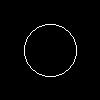

[2024-04-24 18:00:41,409] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)
Loading LLaVA from base model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:14<00:00,  7.23s/it]


Loading additional LLaVA weights...
Loading LoRA weights...
Merging LoRA weights...
Model is loaded...
12.566370614359172


Exception ignored in atexit callback: <function matmul_ext_update_autotune_table at 0x7f2de2e994e0>
Traceback (most recent call last):
  File "/home/kenichi.maeda001/anaconda3/envs/LLMP/lib/python3.11/site-packages/deepspeed/ops/transformer/inference/triton/matmul_ext.py", line 444, in matmul_ext_update_autotune_table
    fp16_matmul._update_autotune_table()
  File "/home/kenichi.maeda001/anaconda3/envs/LLMP/lib/python3.11/site-packages/deepspeed/ops/transformer/inference/triton/matmul_ext.py", line 421, in _update_autotune_table
    TritonMatmul._update_autotune_table(__class__.__name__ + "_2d_kernel", __class__._2d_kernel)
  File "/home/kenichi.maeda001/anaconda3/envs/LLMP/lib/python3.11/site-packages/deepspeed/ops/transformer/inference/triton/matmul_ext.py", line 150, in _update_autotune_table
    cache_manager.put(autotune_table)
  File "/home/kenichi.maeda001/anaconda3/envs/LLMP/lib/python3.11/site-packages/deepspeed/ops/transformer/inference/triton/matmul_ext.py", line 66, in put

KeyboardInterrupt: 

In [2]:
from PIL import Image
import torch
import gc

image = Image.open(IMAGE_FILE)
image.show()

import torch
import re
torch.cuda.empty_cache()

import subprocess
command = f"python {PYTHON_SCRIPT} --model-path {MODEL_PATH} --model-base {MODEL_BASE} --image-file {IMAGE_FILE} --query 'What do you see? If you see a circle, can you estimate the size of the circle in pixels? Please respond with just the range (integer).'"

subprocess.run(command, shell=True)
#output_text = output.stdout

"""
result = re.search(r'(\d+)$', output_text)

if result:
    extracted_number = result.group(1)
    return extracted_number
else:
    print("Number not found.")"""
         




In [25]:
result = re.search(r'(\d+)(?:\.\d+)?$', output_text)

if result:
    extracted_integer = result.group(1)
    print(extracted_integer)
else:
    print("Number not found.")


1386
